# IoT 트래픽 분류 (VPN / Non-VPN Multiclass)

이 노트북은 트래픽 데이터를 바탕으로 VPN 및 Non-VPN 트래픽을 분류하는 딥러닝 모델의 성능을 향상시키는 것을 목표로 합니다.

- 하이퍼파라미터 튜닝은 검증셋(Validation)으로만 수행하며, 최종 성능 보고는 시험셋(Test)으로 진행합니다.
- 3-Run 안정성 검증 시 표본표준편차(ddof=1, n=3)를 산출합니다.

In [1]:
import os
import warnings
os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import urllib.request
import zipfile
import hashlib
from scipy.io import arff
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


## 1. 데이터 다운로드 및 검증
3rd-party GitHub Mirror를 사용하여 ISCX VPN-nonVPN 데이터를 다운로드합니다. MD5 해시를 비교하여 데이터 무결성을 검증합니다.

In [2]:
url = "https://raw.githubusercontent.com/Muzafferrr/DL-ML-with-Brasil-VPN-NON-VPN-Dataset/main/DL%26ML%20with%20VPNNON-VPN%20Dataset.zip"
zip_path = "dataset.zip"
expected_hash = "2bb6ba3386e11c06de6adb3886b59b36"

if not os.path.exists(zip_path):
    urllib.request.urlretrieve(url, zip_path)

with open(zip_path, 'rb') as f:
    file_hash = hashlib.md5(f.read()).hexdigest()

if file_hash != expected_hash:
    raise ValueError(f"Hash mismatch! Expected {expected_hash}, got {file_hash}")
print(f"Downloaded ZIP MD5: {file_hash} (Matched)")

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("Yeni_klasor_temp")

data_path = "Yeni_klasor_temp/Yeni klasör/IscxDataset/ScenarioB/TimeBasedFeatures-Dataset-15s.arff"


Downloaded ZIP MD5: 2bb6ba3386e11c06de6adb3886b59b36 (Matched)


## 2. 데이터 로드 및 전처리 (60/20/20 분할)
문자열 라벨 디코딩 후 중복 행을 제거합니다. 동일 특징 행 충돌 한계점 분석 후 Train/Val/Test 셋으로 분할합니다.

특징 기준 중복/상충 라벨 건수: 41
중복 제거: 18758 -> 18074

--- Class Distribution ---
VOIP: 2821
BROWSING: 2500
VPN-BROWSING: 2500
VPN-VOIP: 2266
VPN-FT: 1883
VPN-CHAT: 1158
P2P: 941
CHAT: 887
FT: 857
VPN-P2P: 666
VPN-STREAMING: 475
STREAMING: 450
VPN-MAIL: 432
MAIL: 238
--------------------------


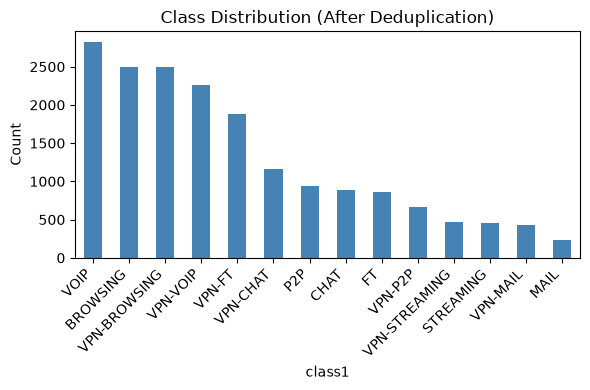

In [3]:
data, meta = arff.loadarff(data_path)
df = pd.DataFrame(data)
df['class1'] = df['class1'].apply(lambda x: x.decode('utf-8'))

# 라벨 충돌 동일 특징 행 분석 
features_only = df.drop('class1', axis=1)
dup_mask = features_only.duplicated(keep=False)
conflict_groups = df[dup_mask].groupby(list(features_only.columns))['class1'].nunique()
conflicting_rows = conflict_groups[conflict_groups > 1]
print(f"특징 기준 중복/상충 라벨 건수: {len(conflicting_rows)}")

initial_len = len(df)
df = df.drop_duplicates()
print(f"중복 제거: {initial_len} -> {len(df)}")

X = df.drop('class1', axis=1).values
y_labels = df['class1'].values

unique_classes = np.unique(y_labels)
class_map = {cls: i for i, cls in enumerate(unique_classes)}
y = np.array([class_map[cls] for cls in y_labels])

# 클래스 분포 시각화용 데이터 산출 
class_counts = df['class1'].value_counts()
print("\n--- Class Distribution ---")
for cls_name, count in class_counts.items():
    print(f"{cls_name}: {count}")
print("--------------------------")

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# 클래스 분포 시각화
fig_dist = plt.figure(figsize=(6,4))
class_counts.plot(kind='bar', color='steelblue')
plt.title('Class Distribution (After Deduplication)')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 3. 머신러닝 기준 모델 학습
비교를 위해 Random Forest를 학습하고 성능을 확인합니다.

In [4]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

rf_test_pred = rf.predict(X_test_scaled)
rf_acc = accuracy_score(y_test, rf_test_pred)
rf_f1 = f1_score(y_test, rf_test_pred, average='macro')
print(f"Random Forest (Test) - Accuracy: {rf_acc:.4f}, F1-Score: {rf_f1:.4f}")


Random Forest (Test) - Accuracy: 0.8614, F1-Score: 0.8294


## 4. 딥러닝 모델 튜닝 (Ablation)
네트워크 구조, 드롭아웃, EarlyStopping 등을 순차적으로 적용하며 검증셋(Val)으로만 평가합니다.
- Step 2: 폭과 깊이 동시 변경
- Step 3: Dropout 추가 (Val Acc 0.5842 -> 0.5651 일부 하락)
- Step 4: Callbacks 추가 및 epoch 15->50 동시 변경 (학습 예산 증가)

In [5]:
def build_baseline():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(32, activation='relu'),
        Dense(len(unique_classes), activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

base_model = build_baseline()
base_model.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val), epochs=15, batch_size=128, verbose=0)
pred_base_val = np.argmax(base_model.predict(X_val_scaled, verbose=0), axis=1)
base_val_acc = accuracy_score(y_val, pred_base_val)
print(f"[Step 1] Baseline DL (Val) - Acc: {base_val_acc:.4f}")

def build_improved_1():
    model = Sequential([
        Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(len(unique_classes), activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

tf.keras.utils.set_random_seed(42)
imp1_model = build_improved_1()
imp1_model.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val), epochs=15, batch_size=128, verbose=0)
pred_imp1_val = np.argmax(imp1_model.predict(X_val_scaled, verbose=0), axis=1)
imp1_val_acc = accuracy_score(y_val, pred_imp1_val)
print(f"[Step 2] Width+Depth Expansion (Val) - Acc: {imp1_val_acc:.4f}")

def build_improved_2():
    model = Sequential([
        Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dense(len(unique_classes), activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

tf.keras.utils.set_random_seed(42)
imp2_model = build_improved_2()
imp2_model.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val), epochs=15, batch_size=128, verbose=0)
pred_imp2_val = np.argmax(imp2_model.predict(X_val_scaled, verbose=0), axis=1)
imp2_val_acc = accuracy_score(y_val, pred_imp2_val)
print(f"[Step 3] Dropout Added (Val) - Acc: {imp2_val_acc:.4f}")

tf.keras.utils.set_random_seed(42)
imp3_model = build_improved_2()
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
imp3_model.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val), epochs=50, batch_size=128, callbacks=[early_stop, lr_schedule], verbose=0)
pred_imp3_val = np.argmax(imp3_model.predict(X_val_scaled, verbose=0), axis=1)
imp3_val_acc = accuracy_score(y_val, pred_imp3_val)
print(f"[Step 4] Callbacks+Epoch50 (Val) - Acc: {imp3_val_acc:.4f}")


[Step 1] Baseline DL (Val) - Acc: 0.5109


[Step 2] Width+Depth Expansion (Val) - Acc: 0.5842


[Step 3] Dropout Added (Val) - Acc: 0.5651


[Step 4] Callbacks+Epoch50 (Val) - Acc: 0.6119


## 5. 안정성 검증 (3-Run)
고정된 시드 3개를 반복하여 신뢰성을 확보하며, 하이퍼파라미터 튜닝은 검증셋(Validation)으로만 수행하고 최종 성능 보고는 시험셋(Test)으로 진행합니다.
(Test 세트 사용: RF 1회, Base 1회, Improved 3회)

In [6]:
seeds = [42, 1004, 2026]
acc_list, f1_list = [], []
final_history, final_model = None, None

for s in seeds:
    tf.keras.utils.set_random_seed(s)
    tf.config.experimental.enable_op_determinism()
    
    model = build_improved_2()
    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
    
    history = model.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val), 
                        epochs=50, batch_size=128, callbacks=[es, lr], verbose=0)
    
    pred_test = np.argmax(model.predict(X_test_scaled, verbose=0), axis=1)
    acc = accuracy_score(y_test, pred_test)
    f1 = f1_score(y_test, pred_test, average='macro')
    
    print(f"Seed {s} Test - Acc: {acc:.4f}, F1: {f1:.4f}")
    acc_list.append(acc)
    f1_list.append(f1)
    
    if s == 42:
        final_history = history
        final_model = model
        pred_base_test = np.argmax(base_model.predict(X_test_scaled, verbose=0), axis=1)
        pred_imp_test = pred_test

acc_mean, acc_std = np.mean(acc_list), np.std(acc_list, ddof=1)
f1_mean, f1_std = np.mean(f1_list), np.std(f1_list, ddof=1)
print(f"[Test 3-Run] Acc = {acc_mean:.4f} ± {acc_std:.4f}, F1 = {f1_mean:.4f} ± {f1_std:.4f}")

base_test_acc = accuracy_score(y_test, pred_base_test)
base_test_f1 = f1_score(y_test, pred_base_test, average='macro')
imp_test_acc = acc_list[0]
imp_test_f1 = f1_list[0]

diff_base_acc = (rf_acc - base_test_acc) * 100
diff_imp_acc = (rf_acc - acc_mean) * 100
diff_imp_single = (rf_acc - imp_test_acc) * 100

imp_acc_gain = acc_mean - base_test_acc
imp_f1_gain = f1_mean - base_test_f1

print(f"Base Single(Test) Acc: {base_test_acc:.4f}, F1: {base_test_f1:.4f}")
print(f"Imp Single(Test) Acc: {imp_test_acc:.4f}, F1: {imp_test_f1:.4f}")
print(f"Diff %p (Base): {diff_base_acc:.2f}%p")
print(f"Diff %p (Imp Mean): {diff_imp_acc:.2f}%p")
print(f"Diff %p (Imp Single): {diff_imp_single:.2f}%p")
print(f"Gain (Acc): +{imp_acc_gain:.4f}")
print(f"Gain (F1): +{imp_f1_gain:.4f}")
print("Test Set Usage: RF(1회), Base(1회), Improved(3회)")


Seed 42 Test - Acc: 0.6003, F1: 0.5172


Seed 1004 Test - Acc: 0.6011, F1: 0.5177


Seed 2026 Test - Acc: 0.5947, F1: 0.5019
[Test 3-Run] Acc = 0.5987 ± 0.0035, F1 = 0.5123 ± 0.0090
Base Single(Test) Acc: 0.4990, F1: 0.3611
Imp Single(Test) Acc: 0.6003, F1: 0.5172
Diff %p (Base): 36.24%p
Diff %p (Imp Mean): 26.27%p
Diff %p (Imp Single): 26.11%p
Gain (Acc): +0.0997
Gain (F1): +0.1512
Test Set Usage: RF(1회), Base(1회), Improved(3회)


## 6. 시각화
학습 곡선과 오차 행렬(Confusion Matrix)을 시각화합니다.

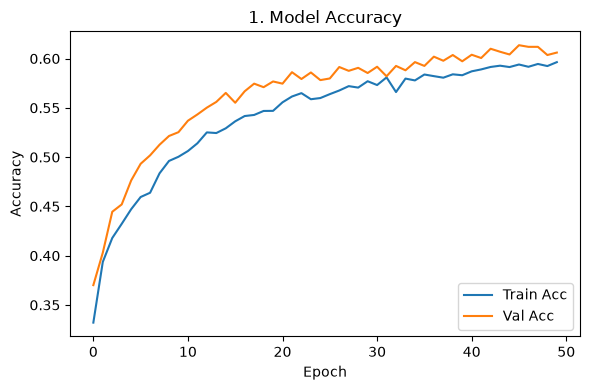

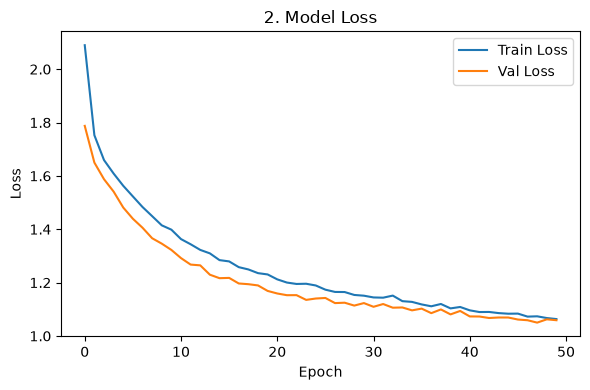

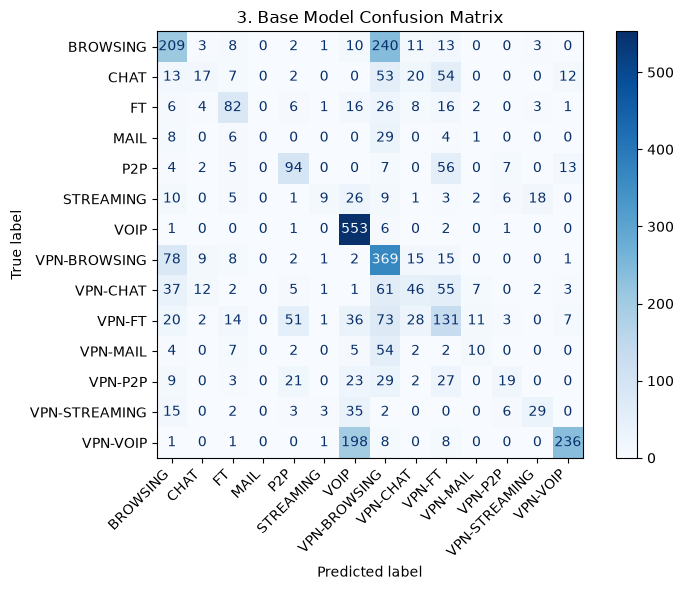

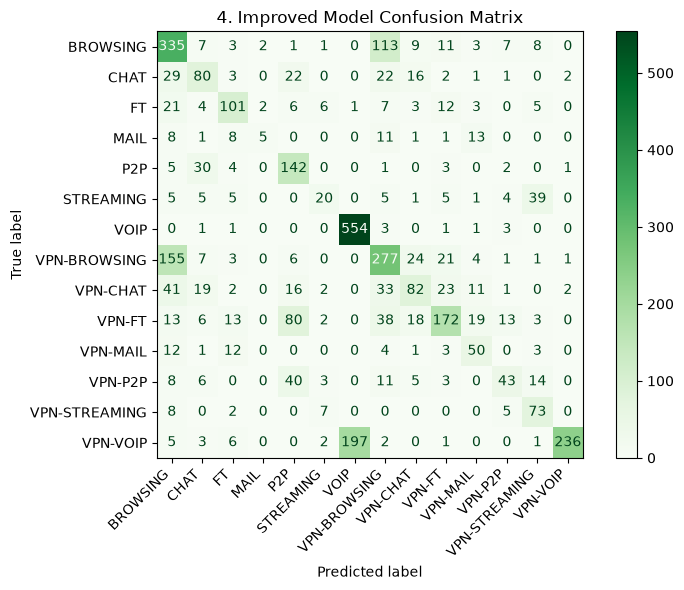

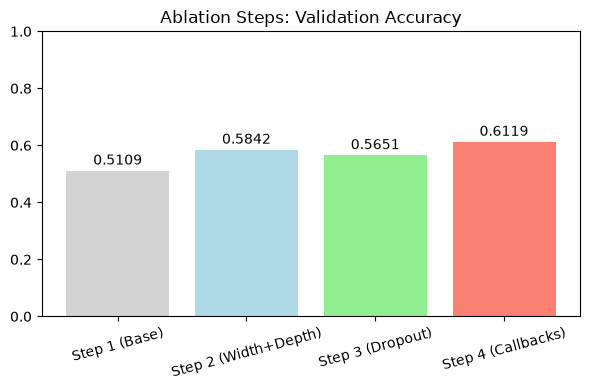

In [7]:
fig1 = plt.figure(figsize=(6,4))
plt.plot(final_history.history['accuracy'], label='Train Acc')
plt.plot(final_history.history['val_accuracy'], label='Val Acc')
plt.title('1. Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

fig2 = plt.figure(figsize=(6,4))
plt.plot(final_history.history['loss'], label='Train Loss')
plt.plot(final_history.history['val_loss'], label='Val Loss')
plt.title('2. Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

fig3 = plt.figure(figsize=(8,6))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_base_test), display_labels=unique_classes).plot(cmap='Blues', ax=plt.gca(), values_format='.0f')
plt.title('3. Base Model Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

fig4 = plt.figure(figsize=(8,6))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_imp_test), display_labels=unique_classes).plot(cmap='Greens', ax=plt.gca(), values_format='.0f')
plt.title('4. Improved Model Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Ablation 성능 비교 시각화 
fig_ablation = plt.figure(figsize=(6,4))
steps = ['Step 1 (Base)', 'Step 2 (Width+Depth)', 'Step 3 (Dropout)', 'Step 4 (Callbacks)']
accs = [base_val_acc, imp1_val_acc, imp2_val_acc, imp3_val_acc]
bars = plt.bar(steps, accs, color=['lightgray', 'lightblue', 'lightgreen', 'salmon'])
plt.title('Ablation Steps: Validation Accuracy')
plt.ylim(0, 1.0)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
